<p>
  <b>AI Lab: Deep Learning for Computer Vision</b><br>
  <b><a href="https://www.wqu.edu/">WorldQuant University</a></b>
</p>

**Task 3.2.6:** Create a variable for the image path using `pathlib` syntax.

In [58]:
image_path = images_dir/"10.jpg"
image = read_image(str(image_path))
print(image.shape)

torch.Size([3, 416, 749])


We can use the `draw_bounding_boxes` function to add the bounding boxes and labels to the image.

In [59]:
image = draw_bounding_boxes(
    image=image,
    boxes=bboxes_tensor,
    labels=labels,
    width=3,
    fill=False,
    font="arial.ttf",
    font_size=10,
)

**Task 3.2.7:** Display the composite image with bounding boxes and labels.

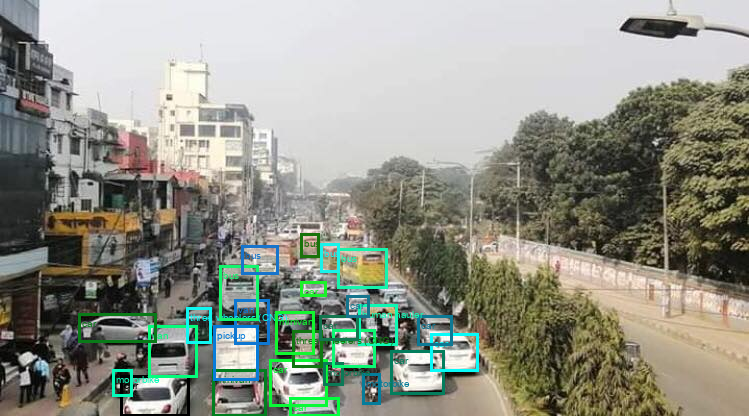

In [60]:
to_pil_image(image)

### YouTube Video Data

Next, we load YouTube video of traffic in Dhaka, Bangladesh.

**Task 3.2.8:** Create a variable for the video directory using `pathlib` syntax.

In [28]:
video_dir = Path("data_video")
video_name = "dhaka_traffic.mp4"
video_path = video_dir/video_name

print(video_path)

data_video/dhaka_traffic.mp4


We are going to capture still images from the video to make it easier to draw bounding boxes.

In [30]:
video_capture = cv2.VideoCapture(video_path)

if not video_capture.isOpened():
    print("Error: Could not open video.")
else:
    frame_rate = video_capture.get(cv2.CAP_PROP_FPS)
    frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Frame rate: {frame_rate}")
    print(f"Total number of frames: {frame_count:,}")

Frame rate: 25.0
Total number of frames: 9,333


Let's look the first frame.

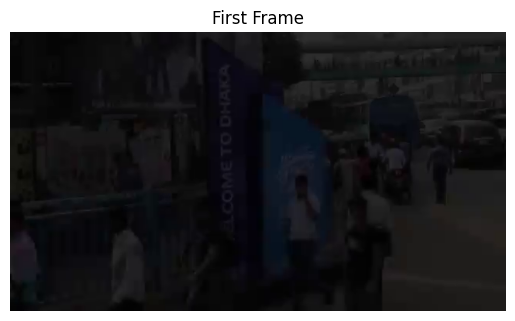

In [35]:
success, first_frame = video_capture.read()
if success:
    plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Error: Could not read frame.")

We were successful in displaying the first frame, however that frame is black. Let's look at a later frame that is more interesting.

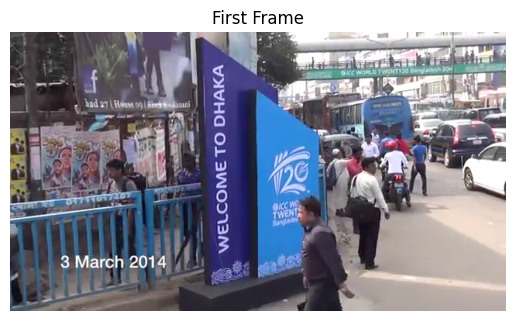

In [36]:
video_capture.set(cv2.CAP_PROP_POS_FRAMES, 100)
success, later_frame = video_capture.read()
if success:
    plt.imshow(cv2.cvtColor(later_frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Error: Could not read frame.")

**Task 3.2.9:** Create a directory for the frames using the `pathlib` syntax.

In [37]:
frames_dir = video_dir/"extracted_frames"
frames_dir.mkdir(exist_ok=True)

Now we walk through the video, saving selected frames as we go.

In [38]:
frame_count = 0

while True:
    success, frame = video_capture.read()
    if not success:
        break

    # Save frames at the frame_rate
    if frame_count % frame_rate == 0:
        frame_path = frames_dir / f"frame_{frame_count}.jpg"
        cv2.imwrite(frame_path, frame)

    frame_count += 1

video_capture.release()

We can look at the frames we have extracted and saved using the `display_sample_images` function.

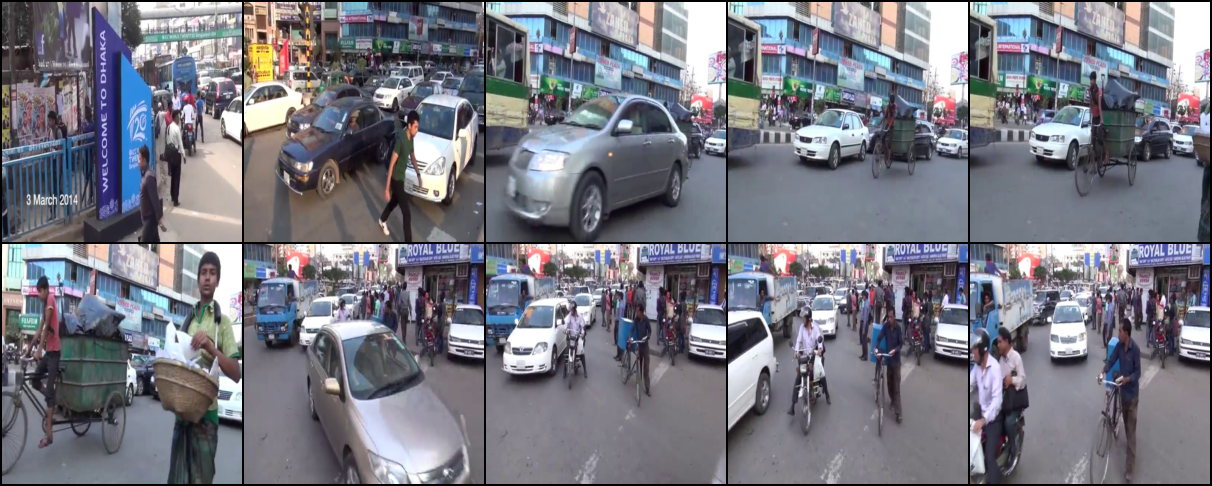

In [39]:
def display_sample_images(dir_path, sample=5):
    image_list = []
    images = sorted(dir_path.iterdir())
    if images:
        sample_images = images[:sample]
        for sample_image in sample_images:
            image = read_image(str(sample_image))
            resize_transform = transforms.Resize((240, 240))
            image = resize_transform(image)
            image_list.append(image)
    grid = make_grid(image_list, nrow=5)
    image = to_pil_image(grid)
    return image


display_sample_images(frames_dir, sample=10)

In [40]:
image_path = frames_dir/"frame_8125.jpg"
image = read_image(str(image_path))
print(image.shape)

torch.Size([3, 360, 640])
